In [ ]:
%pip install -q -U ultralytics roboflow python-dotenv


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 361.2/361.2 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 6.3 MB/s eta 0:00:00


In [5]:
from roboflow import Roboflow
from dotenv import load_dotenv
import os
from ultralytics import YOLO
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# apikeys.env NO debe subirse a git ni compartirse: agrega la carpeta/archivo a .gitignore.
# Crea tu propio apikeys.env junto al notebook con una linea:
#   ROBOFLOW_API_KEY=tu_api_key_aqui
load_dotenv("apikeys.env")

api_key = os.getenv("ROBOFLOW_API_KEY")
if not api_key:
    raise RuntimeError(
        "No se encontro ROBOFLOW_API_KEY. Crea un archivo apikeys.env junto a este "
        "notebook con la linea: ROBOFLOW_API_KEY=tu_api_key_aqui"
    )

In [6]:
rf = Roboflow(api_key=api_key)
project = rf.workspace("roboflow-jvuqo").project("football-players-detection-3zvbc")
dataset = project.version(1).download("yolo26")

print(f"Dataset descargado en: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to football-players-detection-1 in yolo26:: 100%|██████████| 1338/1338 [00:03<00:00, 372.58it/s]

Dataset descargado en: /content/football-players-detection-1


In [8]:
# Cargar el modelo base Nano (el más liviano posible)
model = YOLO("yolo26n.pt")

# Entrenar optimizando el tiempo:
# 1. Reducimos epochs de 20 a 5 o 10.
# 2. Reducimos imgsz de 640 a 320 o 416 (procesa 4 veces más rápido por época).
# 3. Forzamos el uso de GPU si está disponible (device=0 o "cuda").
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=5,       # Reducido de 20 a 5 épocas
    imgsz=320,      # Reducido de 640 a 320 (acelera enormemente el entrenamiento)
    workers=2       # Carga ligera de datos
)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/football-players-detection-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=None, opset=None, opt

In [9]:
import glob

# Ruta portable: tomamos la primera imagen del set de test que se descargo con Roboflow,
# en vez de una ruta absoluta especifica de una maquina/Studio.
test_images = sorted(glob.glob(f"{dataset.location}/test/images/*.jpg"))
assert test_images, f"No se encontraron imagenes de test en {dataset.location}/test/images"
image_path = test_images[0]
print(f"Usando imagen de prueba: {image_path}")

resultados = model(image_path)

Usando imagen de prueba: /content/football-players-detection-1/test/images/40cd38_7_6_png.rf.68ef7fcd663cdf0f5b96bacdbcd94e07.jpg

image 1/1 /content/football-players-detection-1/test/images/40cd38_7_6_png.rf.68ef7fcd663cdf0f5b96bacdbcd94e07.jpg: 192x320 26 players, 63.8ms
Speed: 2.0ms preprocess, 63.8ms inference, 1.2ms postprocess per image at shape (1, 3, 192, 320)


In [10]:
r = resultados[0] # r es un objeto de tipo 'ultralytics.yolo.engine.results.Results' que contiene toda la informacion de la inferencia

print("=== Informacion general ===")
print(f"Imagen original: {r.path}")
print(f"Tamano procesado: {r.orig_shape}")
print(f"Objetos detectados: {len(r.boxes)}")


print("\n=== Detecciones ===")
for i, box in enumerate(r.boxes):
    clase_id  = int(box.cls[0])
    clase_nom = model.names[clase_id]
    confianza = float(box.conf[0])
    x1, y1, x2, y2 = box.xyxy[0].tolist()

    print(f"  [{i+1}] {clase_nom:15s} | confianza: {confianza:.2f} | bbox: ({x1:.0f},{y1:.0f}) → ({x2:.0f},{y2:.0f})")

=== Informacion general ===
Imagen original: /content/football-players-detection-1/test/images/40cd38_7_6_png.rf.68ef7fcd663cdf0f5b96bacdbcd94e07.jpg
Tamano procesado: (1080, 1920)
Objetos detectados: 26

=== Detecciones ===
  [1] player          | confianza: 0.79 | bbox: (545,671) → (580,741)
  [2] player          | confianza: 0.75 | bbox: (1681,611) → (1713,675)
  [3] player          | confianza: 0.74 | bbox: (1141,537) → (1165,605)
  [4] player          | confianza: 0.74 | bbox: (642,543) → (666,599)
  [5] player          | confianza: 0.66 | bbox: (1515,503) → (1541,556)
  [6] player          | confianza: 0.66 | bbox: (1753,679) → (1782,746)
  [7] player          | confianza: 0.65 | bbox: (1819,624) → (1847,686)
  [8] player          | confianza: 0.65 | bbox: (1321,597) → (1351,657)
  [9] player          | confianza: 0.63 | bbox: (791,618) → (818,681)
  [10] player          | confianza: 0.62 | bbox: (161,523) → (187,575)
  [11] player          | confianza: 0.59 | bbox: (900,516) → (

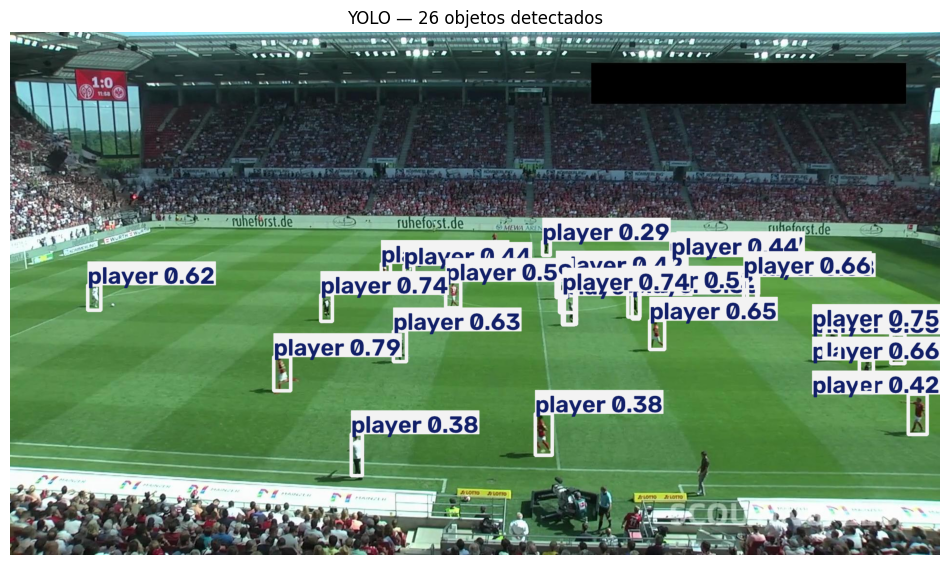

In [11]:

# r.plot() retorna la imagen anotada como array NumPy (BGR → convertir a RGB para matplotlib)
imagen_anotada = r.plot()
imagen_anotada_rgb = imagen_anotada[:, :, ::-1]  # BGR a RGB

plt.figure(figsize=(12, 7))
plt.imshow(imagen_anotada_rgb)
plt.title(f"YOLO — {len(r.boxes)} objetos detectados")
plt.axis("off")
plt.show()